# Loading Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
)
from sklearn.feature_selection import f_classif
from sklearn.decomposition import PCA
from scipy import stats

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

df = pd.read_excel("customer_segmentation_finance_big_balanced.xlsx")
df = df.drop(columns=["customer_id"])
print(df.shape)
df.head()


(30000, 28)


,age,gender,marital_status,city_tier,annual_income_usd,credit_score,savings_rate_pct,loan_amount_usd,product_count,months_with_bank,...,complaints_12m,has_mortgage,has_auto_loan,has_credit_card,salary_account,debt_to_income,engagement_score,risk_score,churn_prob,churn_flag
0,51,F,Married,1,26234,657,15.11,12464,4,324,...,0,0,0,1,1,0.475,0.6693,31.70,0.1488,0
1,39,M,Single,3,41570,661,53.97,4200,1,295,...,0,0,0,0,0,0.101,0.6786,26.74,0.0641,0
2,51,F,Divorced,2,31467,789,55.01,8402,5,124,...,0,0,0,1,1,0.267,0.6594,16.80,0.0063,0
3,33,F,Married,2,60471,850,22.52,17240,8,414,...,0,1,0,1,1,0.285,0.6442,20.21,0.0024,1
4,24,F,Single,2,34676,632,46.85,11669,3,63,...,0,0,0,1,1,0.337,0.6295,27.35,0.2354,0


In [2]:
column_reference = pd.DataFrame({
    "Column": df.columns,
    "dtype": df.dtypes.astype(str)
})
column_reference.to_csv("Column_Reference_Appendix.csv", index=False)
column_reference

,Column,dtype
age,age,int64
gender,gender,object
marital_status,marital_status,object
city_tier,city_tier,int64
annual_income_usd,annual_income_usd,int64
credit_score,credit_score,int64
savings_rate_pct,savings_rate_pct,float64
loan_amount_usd,loan_amount_usd,int64
product_count,product_count,int64
months_with_bank,months_with_bank,int64


# Separating Features from Outcomes (leakage-free design)


In [3]:
OUTCOME_COLS = ["churn_prob", "churn_flag", "risk_score"]

outcome_df = df[OUTCOME_COLS].copy()
features_df = df.drop(columns=OUTCOME_COLS)
print("Feature columns:", list(features_df.columns))


Feature columns: ['age', 'gender', 'marital_status', 'city_tier', 'annual_income_usd', 'credit_score', 'savings_rate_pct', 'loan_amount_usd', 'product_count', 'months_with_bank', 'transaction_count_12m', 'mobile_app_logins_12m', 'branch_visits_12m', 'investment_value_usd', 'insurance_value_usd', 'avg_transaction_amount_usd', 'late_payments_24m', 'overlimit_events_12m', 'complaints_12m', 'has_mortgage', 'has_auto_loan', 'has_credit_card', 'salary_account', 'debt_to_income', 'engagement_score']


# Encoding Categorical Variables

In [4]:
nominal_cols = ["gender", "marital_status"]   # no natural order -> one-hot
features_df = pd.get_dummies(features_df, columns=nominal_cols, drop_first=True)
print(features_df.shape)
features_df.head()


(30000, 27)


,age,city_tier,annual_income_usd,credit_score,savings_rate_pct,loan_amount_usd,product_count,months_with_bank,transaction_count_12m,mobile_app_logins_12m,...,has_mortgage,has_auto_loan,has_credit_card,salary_account,debt_to_income,engagement_score,gender_M,marital_status_Married,marital_status_Single,marital_status_Widowed
0,51,1,26234,657,15.11,12464,4,324,135,64,...,0,0,1,1,0.475,0.6693,False,True,False,False
1,39,3,41570,661,53.97,4200,1,295,119,63,...,0,0,0,0,0.101,0.6786,True,False,True,False
2,51,2,31467,789,55.01,8402,5,124,154,51,...,0,0,1,1,0.267,0.6594,False,False,False,False
3,33,2,60471,850,22.52,17240,8,414,123,61,...,1,0,1,1,0.285,0.6442,False,True,False,False
4,24,2,34676,632,46.85,11669,3,63,124,50,...,0,0,1,1,0.337,0.6295,False,False,True,False


# Scaling

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_df)
feature_names = features_df.columns
X_scaled.shape


(30000, 27)

# Determining the Number of Clusters

In [6]:
K_range = range(2, 11)
inertia, sil_scores, ch_scores, db_scores = [], [], [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

comparison = pd.DataFrame({
    "Number of Clusters": list(K_range),
    "Inertia": inertia,
    "Silhouette Score": sil_scores,
    "Calinski-Harabasz": ch_scores,
    "Davies-Bouldin": db_scores,
})
comparison


,Number of Clusters,Inertia,Silhouette Score,Calinski-Harabasz,Davies-Bouldin
0,2,760921.180228,0.062724,1934.847490,3.829153
1,3,731292.379511,0.064260,1614.262017,3.312249
2,4,700617.313838,0.075242,1561.025447,2.799662
3,5,680513.698283,0.073382,1426.842374,2.805100
4,6,663378.891585,0.058884,1325.866208,2.916555
5,7,650451.796755,0.050099,1226.156401,3.140478
6,8,641442.188944,0.049923,1125.900007,3.030971
7,9,634001.731432,0.048708,1040.685609,3.060649
8,10,625711.255256,0.046439,981.431559,3.046853


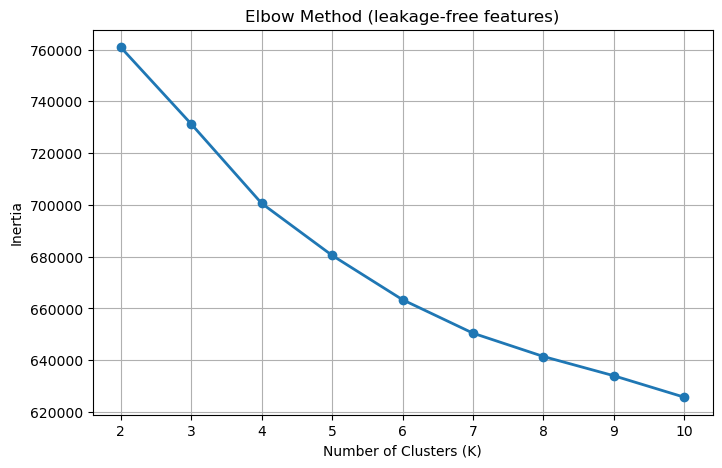

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linewidth=2)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method (leakage-free features)")
plt.grid(True)
plt.savefig("elbow_method.png", dpi=150, bbox_inches="tight")
plt.show()


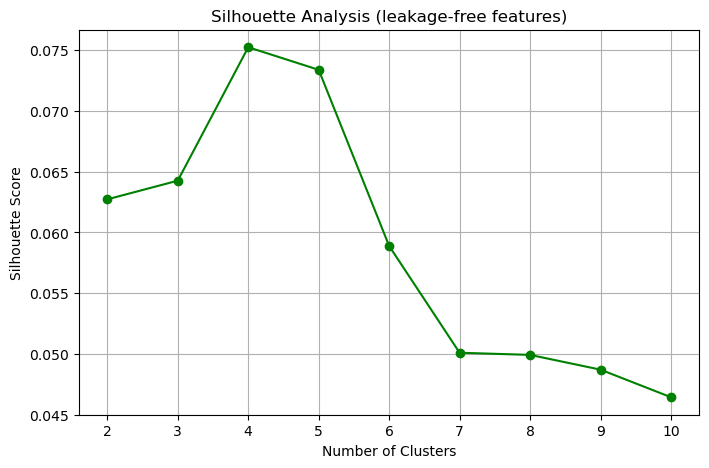

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, sil_scores, marker='o', color='green')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis (leakage-free features)")
plt.grid(True)
plt.savefig("silhouette_analysis.png", dpi=150, bbox_inches="tight")
plt.show()


In [9]:
best_k = int(comparison.loc[comparison["Silhouette Score"].idxmax(), "Number of Clusters"])
print(f"Optimal number of clusters (excluding leakage features): {best_k}")


Optimal number of clusters (excluding leakage features): 4


##  Baseline K-Means Clustering (Euclidean, mixed one-hot features)

### Cluster Sizes

Cluster sizes:
Cluster
0      956
1     2217
2    11757
3    15070
Name: count, dtype: int64


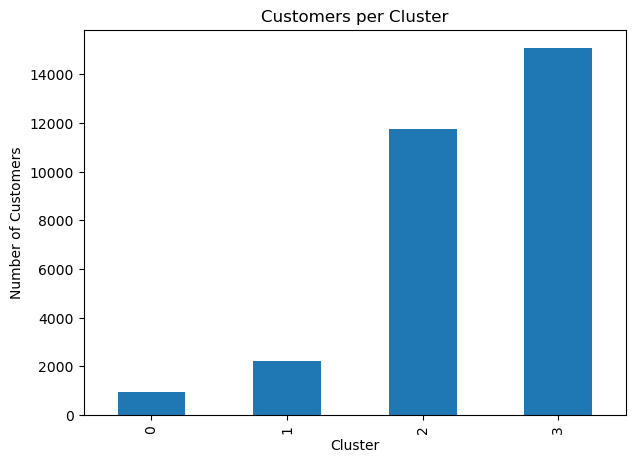

In [10]:
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters
features_df["Cluster"] = clusters

cluster_counts = df["Cluster"].value_counts().sort_index()
print("Cluster sizes:")
print(cluster_counts)

plt.figure(figsize=(7, 5))
cluster_counts.plot(kind="bar")
plt.title("Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.savefig("cluster_sizes.png", dpi=150, bbox_inches="tight")
plt.show()


### Cluster Profiles

In [11]:
cluster_profile = features_df.groupby("Cluster").mean(numeric_only=True)
print("Cluster profile (behavioral / demographic features):")
cluster_profile.to_csv("Cluster_Profile_Behavioral.csv")
cluster_profile


Cluster profile (behavioral / demographic features):


,age,city_tier,annual_income_usd,credit_score,savings_rate_pct,loan_amount_usd,product_count,months_with_bank,transaction_count_12m,mobile_app_logins_12m,...,has_mortgage,has_auto_loan,has_credit_card,salary_account,debt_to_income,engagement_score,gender_M,marital_status_Married,marital_status_Single,marital_status_Widowed
Cluster,,,,,,,,,,,,,,,,,,,,,
0,47.215481,1.822176,38159.100418,699.602510,33.549467,17055.996862,3.168410,210.000000,130.161088,59.878661,...,0.334728,0.284519,0.836820,0.592050,0.497394,0.674322,0.515690,0.000000,0.000000,1.000000
1,47.648173,1.855661,33405.192152,698.401894,34.320478,61669.050519,3.211998,208.863329,129.908886,59.759585,...,0.344159,0.315742,0.842129,0.589535,1.950748,0.674796,0.497970,0.495264,0.376635,0.003608
2,47.462278,1.854129,38996.479119,699.143829,34.286446,14936.238581,3.210258,209.852513,129.994812,60.034703,...,0.348643,0.294803,0.847495,0.599388,0.420127,0.677484,0.503615,0.000000,1.000000,0.000000
3,47.512674,1.855873,39103.113537,699.296417,34.277898,14539.274320,3.221964,211.172395,130.141075,60.095687,...,0.354877,0.302389,0.854081,0.594161,0.407186,0.677855,0.502123,0.835634,0.000000,0.000000


### PCA Visualisation (2D & 3D)

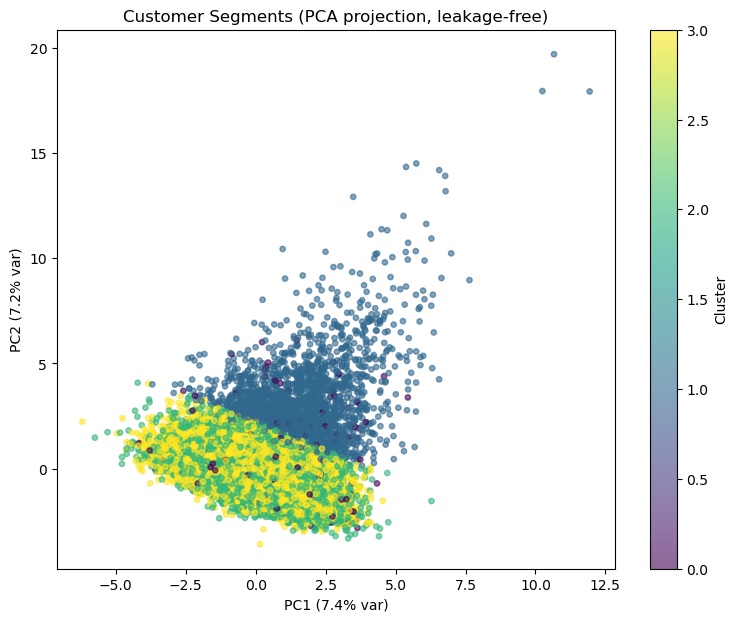

In [12]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    pca_coords[:, 0], pca_coords[:, 1],
    c=clusters, cmap="viridis", s=15, alpha=0.6
)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("Customer Segments (PCA projection, leakage-free)")
plt.colorbar(scatter, label="Cluster")
plt.savefig("pca_clusters.png", dpi=150, bbox_inches="tight")
plt.show()


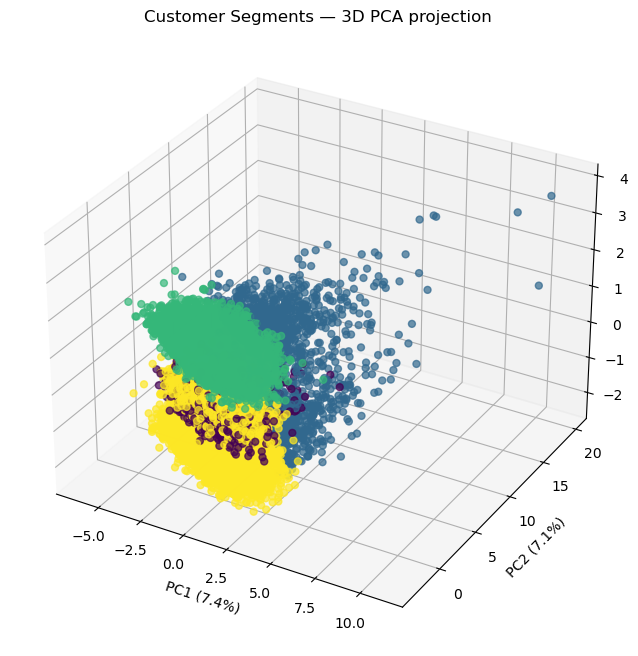

In [13]:
from mpl_toolkits.mplot3d import Axes3D

pca3 = PCA(n_components=3, random_state=RANDOM_STATE)
pca3_coords = pca3.fit_transform(X_scaled)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
scatter = ax.scatter(
    pca3_coords[:, 0], pca3_coords[:, 1], pca3_coords[:, 2],
    c=clusters, cmap="viridis", s=25, alpha=0.7
)
ax.set_xlabel(f"PC1 ({pca3.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca3.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_zlabel(f"PC3 ({pca3.explained_variance_ratio_[2]*100:.1f}%)")
ax.set_title("Customer Segments — 3D PCA projection")
plt.savefig("pca_clusters_3d.png", dpi=150, bbox_inches="tight")
plt.show()


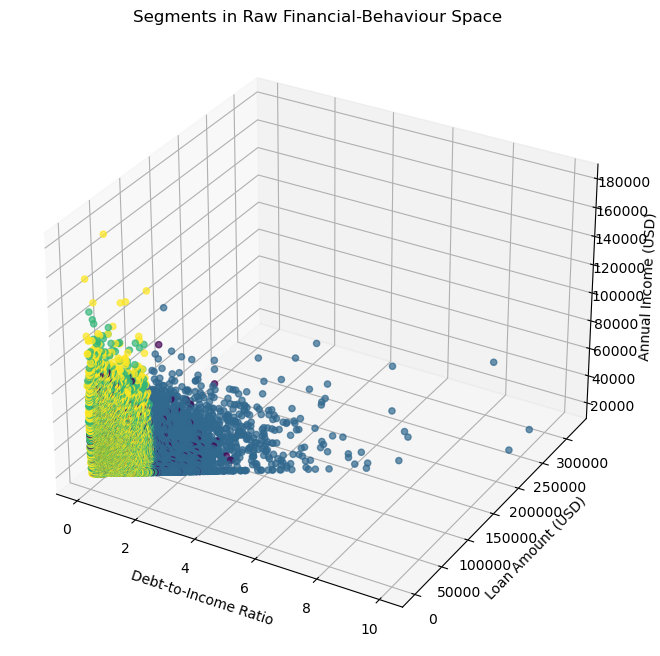

In [14]:
plot_features = ["debt_to_income", "loan_amount_usd", "annual_income_usd"]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
scatter = ax.scatter(
    features_df[plot_features[0]], features_df[plot_features[1]], features_df[plot_features[2]],
    c=clusters, cmap="viridis", s=20, alpha=0.7
)
ax.set_xlabel("Debt-to-Income Ratio")
ax.set_ylabel("Loan Amount (USD)")
ax.set_zlabel("Annual Income (USD)")
ax.set_title("Segments in Raw Financial-Behaviour Space")
plt.savefig("raw_feature_3d.png", dpi=150, bbox_inches="tight")
plt.show()


##  Is Marital Status Business-Relevant to the Segmentation?

It is only useful **if it is a proxy for financial behaviour that the bank cannot observe directly** (household
formation, joint liabilities, dependents, risk appetite). We test this with quantitative evidence and lay
out the qualitative business logic.

### Quantitative Evidence

In [15]:
from scipy.stats import chi2_contingency, kruskal, f_oneway

# (a) Association with churn
ct_churn = pd.crosstab(df["marital_status"], df["churn_flag"])
chi2, p_churn, dof, _ = chi2_contingency(ct_churn)
n = ct_churn.values.sum()
cramers_v_churn = np.sqrt((chi2 / n) / (min(ct_churn.shape) - 1))
print("Marital status vs churn_flag: chi2=%.2f, p=%.4g, Cramer's V=%.3f" % (chi2, p_churn, cramers_v_churn))

# Association with BEHAVIOURAL / FINANCIAL variables
behaviour_vars = [
    "debt_to_income", "product_count", "savings_rate_pct", "loan_amount_usd",
    "investment_value_usd", "insurance_value_usd", "has_mortgage", "has_auto_loan",
]

rows = []
for var in behaviour_vars:
    groups = [g[var].dropna().values for _, g in df.groupby("marital_status")]
    h_stat, p_val = kruskal(*groups)
    means_by_group = df.groupby("marital_status")[var].mean()
    rows.append({
        "Feature": var,
        "Kruskal-Wallis H": h_stat,
        "p-value": p_val,
        "Significant (p<0.05)": p_val < 0.05,
        "Range across marital groups": means_by_group.max() - means_by_group.min(),
    })

marital_relevance = pd.DataFrame(rows).sort_values("p-value")
marital_relevance


Marital status vs churn_flag: chi2=2.78, p=0.4266, Cramer's V=0.010


,Feature,Kruskal-Wallis H,p-value,Significant (p<0.05),Range across marital groups
5,insurance_value_usd,5.042071,0.168742,False,632.026002
4,investment_value_usd,4.852589,0.182915,False,1038.841385
7,has_auto_loan,4.179391,0.242733,False,0.020113
3,loan_amount_usd,2.838633,0.417180,False,563.589711
0,debt_to_income,2.634502,0.451473,False,0.015584
6,has_mortgage,2.609725,0.455787,False,0.027710
2,savings_rate_pct,1.733139,0.629592,False,0.813925
1,product_count,0.980061,0.806076,False,0.050224


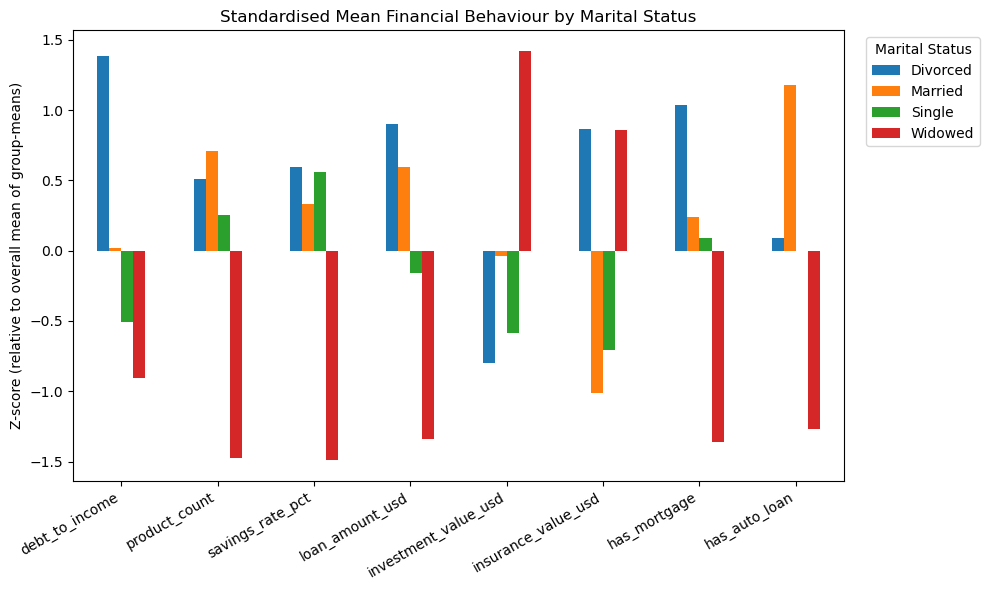

,debt_to_income,product_count,savings_rate_pct,loan_amount_usd,investment_value_usd,insurance_value_usd,has_mortgage,has_auto_loan
marital_status,,,,,,,,
Divorced,0.539352,3.216854,34.341300,18422.513985,29658.789321,14555.770432,0.360697,0.296404
Married,0.530048,3.221386,34.237097,18346.364400,30012.787890,13923.744431,0.351472,0.305383
Single,0.526479,3.210848,34.326031,18156.351652,29759.285658,14026.084975,0.349746,0.295664
Widowed,0.523768,3.171162,33.527376,17858.924274,30697.630705,14553.641079,0.332988,0.285270


In [16]:
# mean of each behavioural variable by marital status
means_table = df.groupby("marital_status")[behaviour_vars].mean()
means_z = (means_table - means_table.mean()) / means_table.std()

plt.figure(figsize=(10, 6))
means_z.T.plot(kind="bar", ax=plt.gca())
plt.title("Standardised Mean Financial Behaviour by Marital Status")
plt.ylabel("Z-score (relative to overall mean of group-means)")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Marital Status", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("marital_status_behaviour.png", dpi=150, bbox_inches="tight")
plt.show()

means_table


##  Business-Relevant, Targetable Segments

###  Outcome Validation by Cluster

In [17]:
validation_df = pd.concat([df[["Cluster"]], outcome_df], axis=1)
validation_summary = validation_df.groupby("Cluster").agg(
    avg_churn_prob=("churn_prob", "mean"),
    churn_rate=("churn_flag", "mean"),
    avg_risk_score=("risk_score", "mean"),
    n_customers=("churn_flag", "count"),
)
validation_summary["share_of_base_pct"] = 100 * validation_summary["n_customers"] / len(df)
validation_summary.to_csv("Cluster_Churn_Validation.csv")
validation_summary


,avg_churn_prob,churn_rate,avg_risk_score,n_customers,share_of_base_pct
Cluster,,,,,
0,0.198808,0.185146,26.733347,956,3.186667
1,0.520888,0.518719,30.281389,2217,7.390000
2,0.175903,0.178957,26.501994,11757,39.190000
3,0.171668,0.170073,26.475373,15070,50.233333


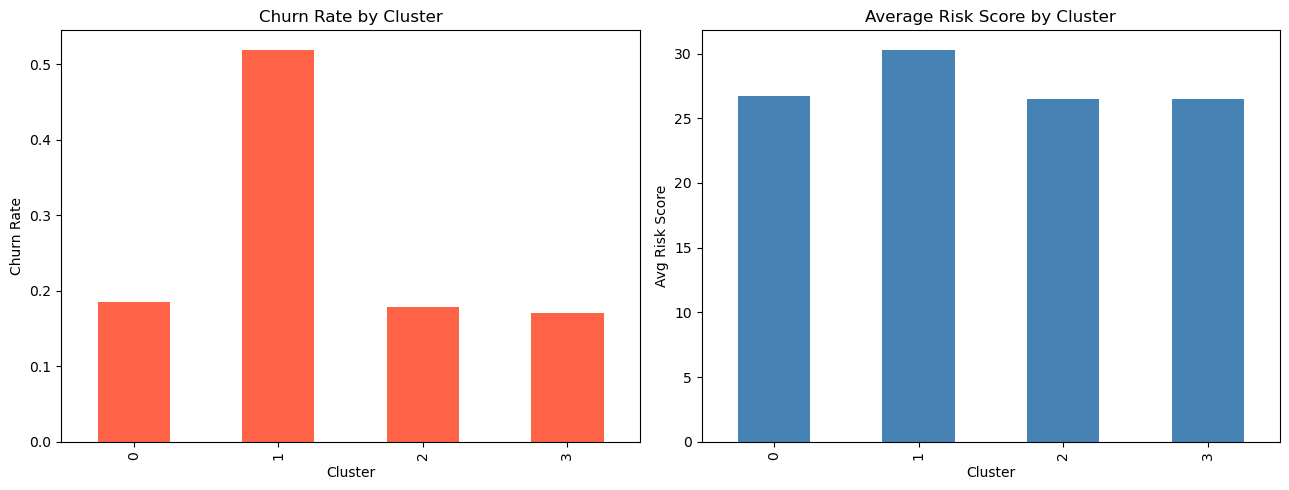

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
validation_summary["churn_rate"].plot(kind="bar", ax=axes[0], color="tomato")
axes[0].set_title("Churn Rate by Cluster")
axes[0].set_ylabel("Churn Rate")
validation_summary["avg_risk_score"].plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Average Risk Score by Cluster")
axes[1].set_ylabel("Avg Risk Score")
plt.tight_layout()
plt.savefig("cluster_risk_churn.png", dpi=150, bbox_inches="tight")
plt.show()


###  The High-Risk / High-Churn Cluster and a Proposed Intervention

In [19]:
# Identify the cluster that ranks highest on BOTH churn and risk 
ranked = validation_summary.copy()
ranked["churn_rank"] = ranked["churn_rate"].rank(ascending=False)
ranked["risk_rank"] = ranked["avg_risk_score"].rank(ascending=False)
ranked["combined_rank_score"] = ranked["churn_rank"] + ranked["risk_rank"]
target_cluster = int(ranked["combined_rank_score"].idxmin())
print(f"Highest-priority cluster for retention intervention: Cluster {target_cluster}")
ranked.sort_values("combined_rank_score")


Highest-priority cluster for retention intervention: Cluster 1


,avg_churn_prob,churn_rate,avg_risk_score,n_customers,share_of_base_pct,churn_rank,risk_rank,combined_rank_score
Cluster,,,,,,,,
1,0.520888,0.518719,30.281389,2217,7.390000,1.0,1.0,2.0
0,0.198808,0.185146,26.733347,956,3.186667,2.0,2.0,4.0
2,0.175903,0.178957,26.501994,11757,39.190000,3.0,3.0,6.0
3,0.171668,0.170073,26.475373,15070,50.233333,4.0,4.0,8.0


In [20]:
profile_of_target = cluster_profile.loc[target_cluster].sort_values(ascending=False)
print(f"Behavioural profile of Cluster {target_cluster} (top distinguishing features vs overall mean):")
overall_mean = features_df.drop(columns="Cluster").mean()
deviation = (cluster_profile.loc[target_cluster] - overall_mean) / overall_mean.replace(0, np.nan).abs()
deviation.sort_values(key=lambda s: s.abs(), ascending=False).head(10)


Behavioural profile of Cluster 1 (top distinguishing features vs overall mean):


debt_to_income            2.686209
loan_amount_usd           2.377658
marital_status_Widowed   -0.887703
annual_income_usd        -0.134808
complaints_12m            0.117577
marital_status_Single    -0.102680
marital_status_Married    0.085232
has_auto_loan             0.053058
overlimit_events_12m     -0.044894
investment_value_usd     -0.025435
dtype: float64

##  Do Categorical Variables Distort the Euclidean Clustering?

### Why One-Hot Codes Inflate Euclidean Distance

One-hot encoding turns a single categorical variable into several binary (0/1) columns. After
z-score standardisation, each of those binary columns can contribute a comparatively large jump
(0 → 1 is a large jump relative to its own standard deviation for an imbalanced binary column) to the squared
Euclidean distance used by K-Means, even though conceptually the variable carries "one unit" of information.
With `gender` (1 dummy) and `marital_status` (3 dummies) totalling 4 of the 26 input columns, this can bias
K-Means toward splitting primarily along categorical boundaries rather than continuous behavioural gradients.
We test this directly below rather than asserting it.

### Numeric-only K-Means vs Full-Feature K-Means (Adjusted Rand Index)

In [21]:
numeric_cols = [c for c in features_df.columns if c not in
                ["Cluster", "gender_M", "marital_status_Married", "marital_status_Single", "marital_status_Widowed"]]
# (drop_first=True in get_dummies means the exact dummy names depend on category order; fetch them robustly)
dummy_cols = [c for c in features_df.columns if c.startswith("gender_") or c.startswith("marital_status_")]
numeric_cols = [c for c in features_df.columns if c not in dummy_cols + ["Cluster"]]

X_numeric_only = StandardScaler().fit_transform(features_df[numeric_cols])

km_numeric = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
clusters_numeric_only = km_numeric.fit_predict(X_numeric_only)

ari = adjusted_rand_score(clusters, clusters_numeric_only)
print(f"Adjusted Rand Index (full one-hot model vs numeric-only model): {ari:.3f}")
print("(1.0 = identical partitions, 0.0 = no better than random agreement)")

sil_numeric = silhouette_score(X_numeric_only, clusters_numeric_only)
print(f"Silhouette score, numeric-only clustering: {sil_numeric:.3f}  (vs full-feature: {sil_scores[best_k-2]:.3f})")


Adjusted Rand Index (full one-hot model vs numeric-only model): 0.093
(1.0 = identical partitions, 0.0 = no better than random agreement)
Silhouette score, numeric-only clustering: 0.061  (vs full-feature: 0.075)


In [22]:
ari_numeric = adjusted_rand_score(clusters, KMeans(n_clusters=best_k, random_state=42, n_init=10).fit_predict(X_numeric_only))

###  Hierarchical Clustering with Alternative Distance Metrics

In [23]:
SAMPLE_N = 3000
sample_idx = df.sample(n=SAMPLE_N, random_state=RANDOM_STATE).index
X_sample = X_scaled[df.index.get_indexer(sample_idx)]

metrics_to_try = {
    "euclidean": "ward",
    "manhattan": "average",
    "cosine": "average",
}

hier_results = []
hier_labels = {}
for metric, linkage in metrics_to_try.items():
    agg = AgglomerativeClustering(n_clusters=best_k, metric=metric, linkage=linkage)
    labels = agg.fit_predict(X_sample)
    hier_labels[metric] = labels
    sil = silhouette_score(X_sample, labels, metric=metric)
    hier_results.append({"Distance metric": metric, "Linkage": linkage, "Silhouette (own metric)": sil})

hier_compare = pd.DataFrame(hier_results)
hier_compare


,Distance metric,Linkage,Silhouette (own metric)
0,euclidean,ward,0.046433
1,manhattan,average,0.200397
2,cosine,average,0.091036


In [24]:
ari_euclidean_manhattan = adjusted_rand_score(hier_labels["euclidean"], hier_labels["manhattan"])
ari_euclidean_cosine = adjusted_rand_score(hier_labels["euclidean"], hier_labels["cosine"])
print(f"ARI (Euclidean vs Manhattan hierarchical clustering): {ari_euclidean_manhattan:.3f}")
print(f"ARI (Euclidean vs Cosine hierarchical clustering):    {ari_euclidean_cosine:.3f}")


ARI (Euclidean vs Manhattan hierarchical clustering): 0.010
ARI (Euclidean vs Cosine hierarchical clustering):    0.440


###  Gower-Distance Clustering (proper mixed-type distance)

Gower distance computes a normalised Manhattan (range-scaled) distance for numeric columns and simple matching (0/1) for categorical columns, then averages per-feature distances — so a categorical variable contributes **exactly one "unit"** regardless of how many one-hot
columns it was expanded into.

In [25]:
def gower_distance_matrix(data: pd.DataFrame, cat_cols):
    # Custom Gower distance 
    data = data.reset_index(drop=True)
    n = len(data)
    num_cols = [c for c in data.columns if c not in cat_cols]

    # Per-feature distance matrices, averaged at the end
    dist_sum = np.zeros((n, n))
    n_features = 0

    for col in num_cols:
        vals = data[col].values.astype(float)
        rng = vals.max() - vals.min()
        if rng == 0:
            continue
        diff = np.abs(vals[:, None] - vals[None, :]) / rng
        dist_sum += diff
        n_features += 1

    for col in cat_cols:
        vals = data[col].astype(str).to_numpy(dtype=object)
        mismatch = (vals[:, None] != vals[None, :]).astype(float)
        dist_sum += mismatch
        n_features += 1

    return dist_sum / n_features

raw_sample = df.loc[sample_idx, [
    "age", "annual_income_usd", "credit_score", "savings_rate_pct", "loan_amount_usd",
    "product_count", "months_with_bank", "transaction_count_12m", "mobile_app_logins_12m",
    "branch_visits_12m", "investment_value_usd", "insurance_value_usd",
    "avg_transaction_amount_usd", "late_payments_24m", "overlimit_events_12m",
    "complaints_12m", "has_mortgage", "has_auto_loan", "has_credit_card", "salary_account",
    "debt_to_income", "engagement_score", "gender", "marital_status",
]].copy()

gower_D = gower_distance_matrix(raw_sample, cat_cols=["gender", "marital_status"])

agg_gower = AgglomerativeClustering(n_clusters=best_k, metric="precomputed", linkage="average")
gower_labels = agg_gower.fit_predict(gower_D)

sil_gower = silhouette_score(gower_D, gower_labels, metric="precomputed")
print(f"Silhouette score, Gower-distance clustering: {sil_gower:.3f}")

ari_euclidean_gower = adjusted_rand_score(hier_labels["euclidean"], gower_labels)
print(f"ARI (Euclidean hierarchical vs Gower hierarchical): {ari_euclidean_gower:.3f}")


Silhouette score, Gower-distance clustering: 0.054
ARI (Euclidean hierarchical vs Gower hierarchical): 0.001


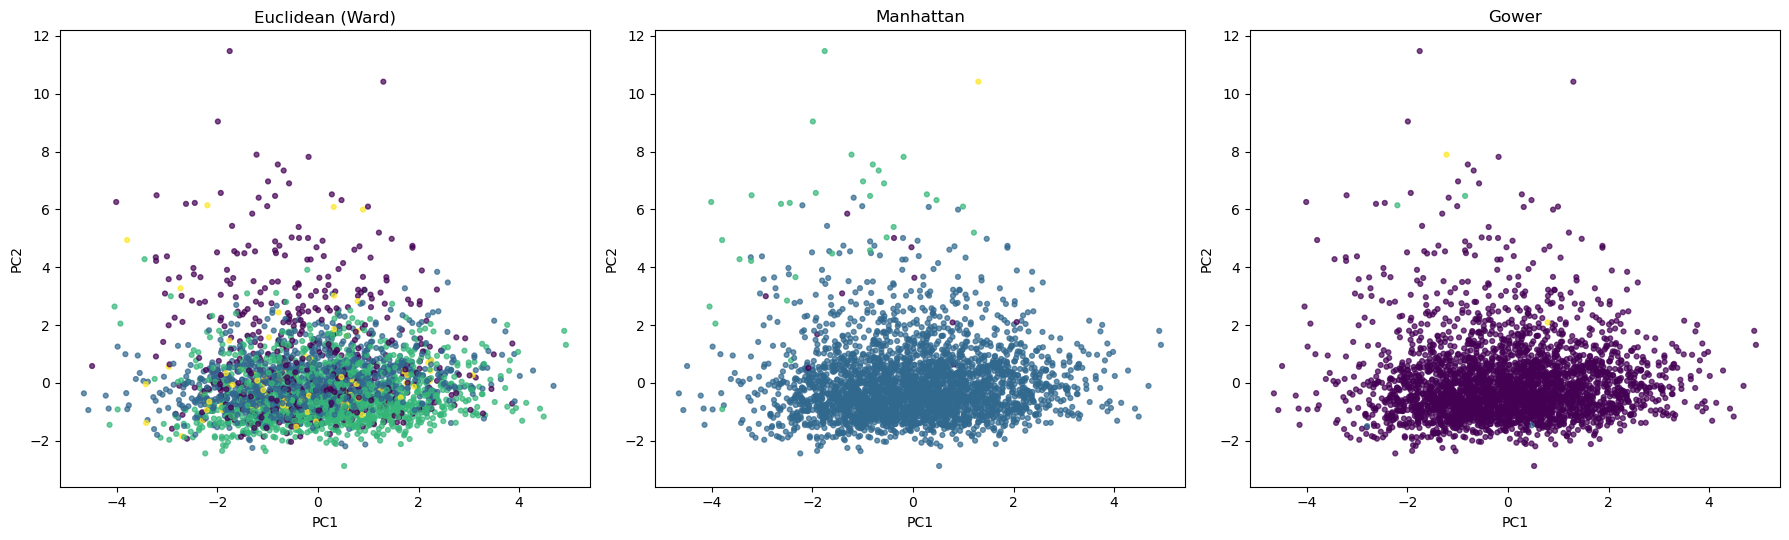

In [26]:
pca_sample = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_sample)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, (name, labels) in zip(axes, [("Euclidean (Ward)", hier_labels["euclidean"]),
                                       ("Manhattan", hier_labels["manhattan"]),
                                       ("Gower", gower_labels)]):
    sc = ax.scatter(pca_sample[:, 0], pca_sample[:, 1], c=labels, cmap="viridis", s=12, alpha=0.7)
    ax.set_title(name)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
plt.tight_layout()
plt.savefig("distance_metric_comparison.png", dpi=150, bbox_inches="tight")
plt.show()



### Business-Rule Composite Score & Group Definition

We define a transparent, auditable **Customer Priority Score** combining (a) profitability/value to the bank
and (b) risk/cost of servicing, so the split is business-defensible rather than an arbitrary unsupervised
artefact:

priority_score = z(value) − z(risk_score) − z(churn_prob)
where value = annual_income_usd + investment_value_usd + insurance_value_usd + 5,000 × product_count

In [27]:
value_raw = (
    df["annual_income_usd"] + df["investment_value_usd"] + df["insurance_value_usd"]
    + 5000 * df["product_count"]
)

def z(s):
    return (s - s.mean()) / s.std()

priority_score = z(value_raw) - z(df["risk_score"]) - z(df["churn_prob"])
df["priority_score"] = priority_score

median_score = df["priority_score"].median()
df["target_group"] = np.where(df["priority_score"] > median_score, "Retain", "Do Not Encourage")

print(df["target_group"].value_counts())
df[["priority_score", "target_group"]].describe(include="all")


target_group
Do Not Encourage    15000
Retain              15000
Name: count, dtype: int64


,priority_score,target_group
count,3.000000e+04,30000
unique,NaN,2
top,NaN,Do Not Encourage
freq,NaN,15000
mean,-4.357995e-17,NaN
std,2.159040e+00,NaN
min,-8.574847e+00,NaN
25%,-1.196605e+00,NaN
50%,2.662802e-01,NaN
75%,1.451555e+00,NaN


### Statistical Comparison of the Two Groups

In [28]:
compare_vars = [
    "annual_income_usd", "credit_score", "product_count", "investment_value_usd",
    "insurance_value_usd", "debt_to_income", "engagement_score", "risk_score", "churn_prob",
    "late_payments_24m", "overlimit_events_12m", "complaints_12m",
]

group_compare = df.groupby("target_group")[compare_vars].mean().T
group_compare["difference"] = group_compare["Retain"] - group_compare["Do Not Encourage"]

sig_rows = []
for var in compare_vars:
    a = df.loc[df["target_group"] == "Retain", var]
    b = df.loc[df["target_group"] == "Do Not Encourage", var]
    t_stat, p_val = stats.ttest_ind(a, b, equal_var=False)
    sig_rows.append({"Feature": var, "t-stat": t_stat, "p-value": p_val})
sig_df = pd.DataFrame(sig_rows).set_index("Feature")

group_compare = group_compare.join(sig_df)
group_compare


,Do Not Encourage,Retain,difference,t-stat,p-value
annual_income_usd,34816.194067,42404.135067,7587.941000,49.865971,0.000000e+00
credit_score,666.861800,731.498733,64.636933,92.102201,0.000000e+00
product_count,2.949533,3.480333,0.530800,26.112190,1.252342e-148
investment_value_usd,24853.856067,34937.955067,10084.099000,41.944403,0.000000e+00
insurance_value_usd,11736.700600,16353.178933,4616.478333,28.790383,1.271533e-179
debt_to_income,0.665003,0.393400,-0.271603,-44.491275,0.000000e+00
engagement_score,0.670569,0.684174,0.013605,22.429547,1.650703e-110
risk_score,30.748671,22.801911,-7.946759,-152.629855,0.000000e+00
churn_prob,0.354068,0.045932,-0.308137,-129.621977,0.000000e+00
late_payments_24m,1.377600,1.035667,-0.341933,-27.286722,6.252550e-162


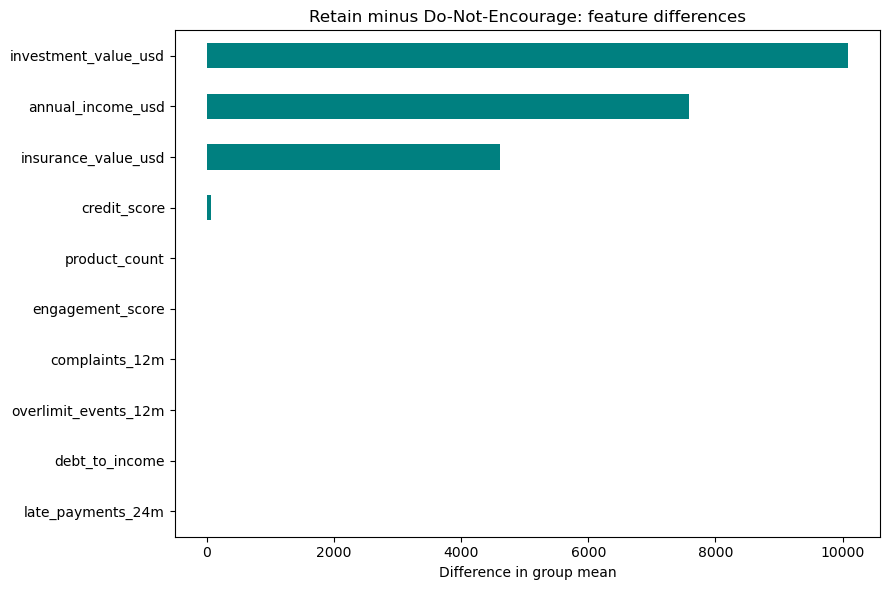

In [29]:
fig, ax = plt.subplots(figsize=(9, 6))
group_compare["difference"].drop(["risk_score", "churn_prob"]).sort_values().plot(kind="barh", ax=ax, color="teal")
ax.set_title("Retain minus Do-Not-Encourage: feature differences")
ax.set_xlabel("Difference in group mean")
plt.tight_layout()
plt.savefig("retain_vs_donotencourage_features.png", dpi=150, bbox_inches="tight")
plt.show()


In [30]:
import statsmodels.api as sm

confounders = ["annual_income_usd", "credit_score", "engagement_score", "age", "product_count"]
X_causal = sm.add_constant(df[["debt_to_income", "loan_amount_usd"] + confounders])
y_causal = df["churn_flag"]

logit_model = sm.Logit(y_causal, X_causal).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.370486
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:             churn_flag   No. Observations:                30000
Model:                          Logit   Df Residuals:                    29992
Method:                           MLE   Df Model:                            7
Date:                Fri, 31 Jul 2026   Pseudo R-squ.:                  0.2592
Time:                        19:56:18   Log-Likelihood:                -11115.
converged:                       True   LL-Null:                       -15004.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                19.4153      0.348     55.788      0.000      18.733      20.097
debt_to_

In [31]:
from sklearn.neighbors import NearestNeighbors

df["debt_group"] = pd.qcut(df["debt_to_income"], 3, labels=["Low", "Mid", "High"])
high = df[df["debt_group"] == "High"]
low = df[df["debt_group"] == "Low"]

match_features = ["annual_income_usd", "credit_score", "engagement_score", "age"]
scaler_m = StandardScaler().fit(df[match_features])
nn = NearestNeighbors(n_neighbors=1).fit(scaler_m.transform(low[match_features]))
dist, idx = nn.kneighbors(scaler_m.transform(high[match_features]))
matched_low = low.iloc[idx.flatten()]

print("Churn rate, High debt-to-income:", high["churn_flag"].mean())
print("Churn rate, matched Low debt-to-income:", matched_low["churn_flag"].mean())

Churn rate, High debt-to-income: 0.318873973151673
Churn rate, matched Low debt-to-income: 0.13564415948707673


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

X_base = df[["debt_to_income", "loan_amount_usd"] + confounders]
X_with_cluster = pd.concat([X_base, pd.get_dummies(df["Cluster"], prefix="cluster", drop_first=True)], axis=1)

auc_base = roc_auc_score(df["churn_flag"], LogisticRegression(max_iter=1000).fit(X_base, df["churn_flag"]).predict_proba(X_base)[:,1])
auc_with_cluster = roc_auc_score(df["churn_flag"], LogisticRegression(max_iter=1000).fit(X_with_cluster, df["churn_flag"]).predict_proba(X_with_cluster)[:,1])

print(f"AUC without cluster label: {auc_base:.4f}")
print(f"AUC with cluster label added: {auc_with_cluster:.4f}")

AUC without cluster label: 0.7294
AUC with cluster label added: 0.7294


### Decision Tree Validation of Cluster 1

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import pandas as pd

In [34]:
# Binary target: Cluster 1 vs all others
X = features_df.drop(columns=["Cluster"])
y = (features_df["Cluster"] == 1).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [35]:
dt_cluster1 = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=50,
    random_state=42
)

dt_cluster1.fit(X_train, y_train)
y_pred = dt_cluster1.predict(X_test)

In [36]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.9925
Precision: 0.9585253456221198
Recall   : 0.9390519187358917
F1-score : 0.9486887115165337

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5557
           1       0.96      0.94      0.95       443

    accuracy                           0.99      6000
   macro avg       0.98      0.97      0.97      6000
weighted avg       0.99      0.99      0.99      6000



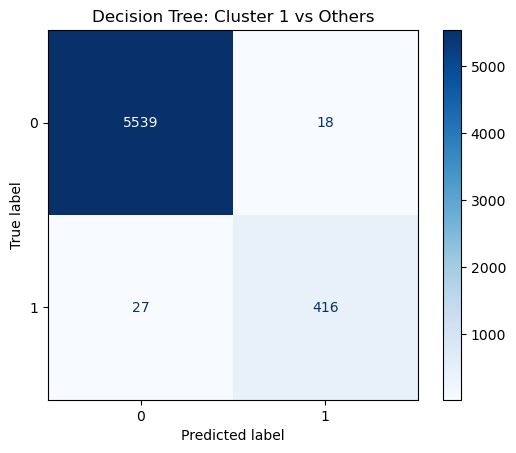

In [37]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Decision Tree: Cluster 1 vs Others")
plt.show()

In [38]:
importance = pd.Series(
    dt_cluster1.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.head(15)

debt_to_income            0.813428
loan_amount_usd           0.158896
marital_status_Widowed    0.025121
marital_status_Single     0.001843
annual_income_usd         0.000547
investment_value_usd      0.000130
months_with_bank          0.000035
complaints_12m            0.000000
marital_status_Married    0.000000
gender_M                  0.000000
engagement_score          0.000000
salary_account            0.000000
has_credit_card           0.000000
has_auto_loan             0.000000
has_mortgage              0.000000
dtype: float64

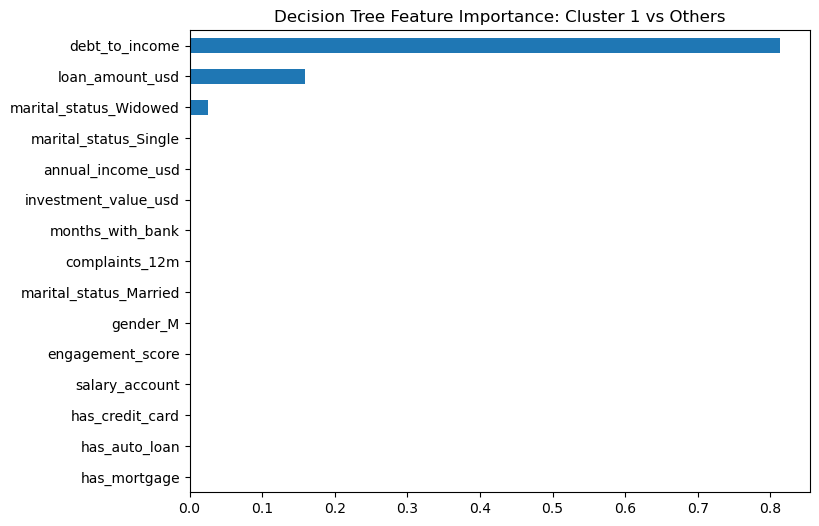

In [39]:
importance.head(15).plot(kind="barh", figsize=(8, 6))
plt.gca().invert_yaxis()
plt.title("Decision Tree Feature Importance: Cluster 1 vs Others")
plt.show()

## Predicting risk_score via Regression

In [40]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

reg_features = features_df.drop(columns=["Cluster"]).columns.tolist()
X_reg = features_df[reg_features].values
y_reg = df["risk_score"].values

# stratify-free random split (regression target) — 75/25
rng = np.random.RandomState(RANDOM_STATE)
perm = rng.permutation(len(X_reg))
n_train = int(0.75 * len(X_reg))
train_idx, test_idx = perm[:n_train], perm[n_train:]

X_reg_train, X_reg_test = X_reg[train_idx], X_reg[test_idx]
y_reg_train, y_reg_test = y_reg[train_idx], y_reg[test_idx]

reg_scaler = StandardScaler().fit(X_reg_train)
X_reg_train_s = reg_scaler.transform(X_reg_train)
X_reg_test_s = reg_scaler.transform(X_reg_test)

print(f"Train size: {len(X_reg_train)}, Test size: {len(X_reg_test)}")


Train size: 22500, Test size: 7500


### Linear, Ridge, Random Forest, Gradient Boosting Regressors

In [41]:
regressors = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

reg_results = []
fitted_regressors = {}
for name, model in regressors.items():
    model.fit(X_reg_train_s, y_reg_train)
    preds = model.predict(X_reg_test_s)
    r2 = r2_score(y_reg_test, preds)
    rmse = np.sqrt(mean_squared_error(y_reg_test, preds))
    mae = mean_absolute_error(y_reg_test, preds)
    reg_results.append({"Model": name, "R2": r2, "RMSE": rmse, "MAE": mae})
    fitted_regressors[name] = model

reg_results_df = pd.DataFrame(reg_results).sort_values("R2", ascending=False)
reg_results_df.to_csv("Risk_Score_Regression_Comparison.csv", index=False)
reg_results_df


,Model,R2,RMSE,MAE
0,Linear Regression,1.000000,0.002923,0.002544
1,Ridge Regression,1.000000,0.002942,0.002553
3,Gradient Boosting,0.995578,0.402275,0.293898
2,Random Forest,0.981471,0.823476,0.535394


###  Model Comparison & Feature Importance

Best model by R2 on held-out test set: Linear Regression


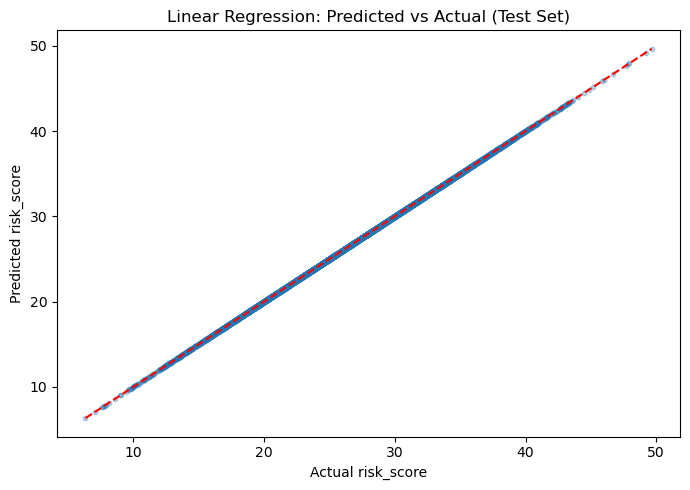

In [42]:
best_reg_name = reg_results_df.iloc[0]["Model"]
best_reg = fitted_regressors[best_reg_name]
print(f"Best model by R2 on held-out test set: {best_reg_name}")

fig, ax = plt.subplots(figsize=(7, 5))
preds_best = best_reg.predict(X_reg_test_s)
ax.scatter(y_reg_test, preds_best, alpha=0.3, s=10)
lims = [min(y_reg_test.min(), preds_best.min()), max(y_reg_test.max(), preds_best.max())]
ax.plot(lims, lims, "r--", linewidth=1.5)
ax.set_xlabel("Actual risk_score")
ax.set_ylabel("Predicted risk_score")
ax.set_title(f"{best_reg_name}: Predicted vs Actual (Test Set)")
plt.tight_layout()
plt.savefig("risk_score_pred_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()


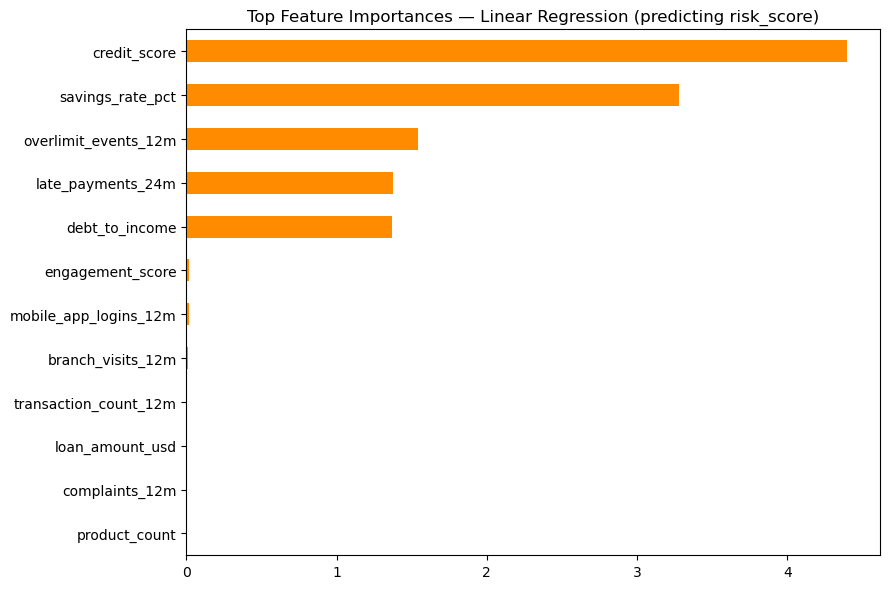

credit_score             4.397198
savings_rate_pct         3.276438
overlimit_events_12m     1.544595
late_payments_24m        1.376802
debt_to_income           1.370272
engagement_score         0.019667
mobile_app_logins_12m    0.016714
branch_visits_12m        0.008542
transaction_count_12m    0.006106
loan_amount_usd          0.000102
complaints_12m           0.000036
product_count            0.000028
dtype: float64

In [43]:
if hasattr(best_reg, "feature_importances_"):
    importances = pd.Series(best_reg.feature_importances_, index=reg_features).sort_values(ascending=False)
elif hasattr(best_reg, "coef_"):
    importances = pd.Series(np.abs(best_reg.coef_), index=reg_features).sort_values(ascending=False)
else:
    importances = pd.Series(dtype=float)

plt.figure(figsize=(9, 6))
importances.head(12).sort_values().plot(kind="barh", color="darkorange")
plt.title(f"Top Feature Importances — {best_reg_name} (predicting risk_score)")
plt.tight_layout()
plt.savefig("risk_score_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

importances.head(12)


In [44]:
pip install minisom

Note: you may need to restart the kernel to use updated packages.


###  SOM Training

In [45]:
from minisom import MiniSom

SOM_X, SOM_Y = 10, 10  # 100-neuron grid
som = MiniSom(
    x=SOM_X, y=SOM_Y, input_len=X_scaled.shape[1],
    sigma=1.5, learning_rate=0.5, random_seed=RANDOM_STATE,
)
som.random_weights_init(X_scaled)
som.train_random(X_scaled, num_iteration=15000)
print("SOM training complete.")

# Quantisation error: average distance between each sample and its Best Matching Unit (BMU)
q_error = som.quantization_error(X_scaled)
print(f"Quantisation error: {q_error:.4f}")


SOM training complete.
Quantisation error: 4.1640


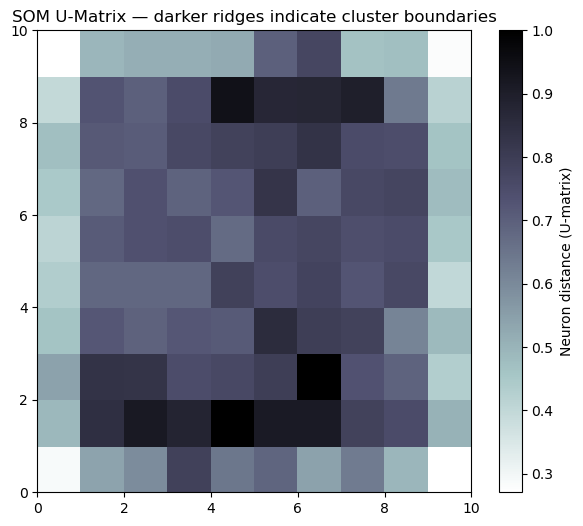

In [46]:
# U-Matrix visualisation (distance between neighbouring neurons shows natural cluster boundaries)
u_matrix = som.distance_map()
plt.figure(figsize=(7, 6))
plt.pcolor(u_matrix.T, cmap="bone_r")
plt.colorbar(label="Neuron distance (U-matrix)")
plt.title("SOM U-Matrix — darker ridges indicate cluster boundaries")
plt.savefig("som_umatrix.png", dpi=150, bbox_inches="tight")
plt.show()


### Collapsing the SOM Grid into 2 Clusters

In [47]:
# Every sample maps to a Best Matching Unit (BMU) neuron on the grid.
bmu_indices = np.array([som.winner(x) for x in X_scaled])
bmu_flat = bmu_indices[:, 0] * SOM_Y + bmu_indices[:, 1]

# Cluster the neuron WEIGHT VECTORS (not the raw data) into 2 groups 
# "SOM + K-means on codebook vectors" two-stage clustering approach.
neuron_weights = som.get_weights().reshape(-1, X_scaled.shape[1])
neuron_kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
neuron_cluster_of = neuron_kmeans.fit_predict(neuron_weights)  # cluster label per neuron (flat index)

som_cluster = neuron_cluster_of[bmu_flat]
df["SOM_Cluster"] = som_cluster

print(pd.Series(som_cluster).value_counts())


1    16110
0    13890
Name: count, dtype: int64


### Clustering Without Marital Status Features

In [48]:
X_original = features_df.drop(columns=["Cluster"])
marital_cols = [c for c in X_original.columns if c.startswith("marital_status_")]
X_no_marital = X_original.drop(columns=marital_cols)

In [49]:
scaler_nm = StandardScaler()
X_no_marital_scaled = scaler_nm.fit_transform(X_no_marital)

In [50]:
results_nm = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_no_marital_scaled)
    results_nm.append({
        "k": k,
        "Inertia": km.inertia_,
        "Silhouette": silhouette_score(X_no_marital_scaled, labels),
        "Calinski-Harabasz": calinski_harabasz_score(X_no_marital_scaled, labels),
        "Davies-Bouldin": davies_bouldin_score(X_no_marital_scaled, labels)
    })

results_nm_df = pd.DataFrame(results_nm)
results_nm_df

,k,Inertia,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,2,681613.281658,0.051855,1689.423071,4.127299
1,3,650874.529995,0.055376,1592.903215,3.488461
2,4,628333.971953,0.058195,1458.681190,3.270424
3,5,611725.628730,0.056344,1327.269061,3.169354
4,6,603913.614554,0.046055,1153.114749,3.271602
5,7,590487.265462,0.046120,1096.405020,3.159594
6,8,581639.995507,0.040424,1019.212732,3.299664
7,9,571994.149895,0.045242,970.037472,2.955101
8,10,565192.104349,0.038081,912.708779,3.074509


In [51]:
# Which SOM cluster corresponds to higher priority_score - label it "Retain" for comparability
som_priority_means = df.groupby("SOM_Cluster")["priority_score"].mean()
retain_som_label = int(som_priority_means.idxmax())
df["SOM_target_group"] = np.where(df["SOM_Cluster"] == retain_som_label, "Retain", "Do Not Encourage")

print("Mean priority_score by SOM cluster:")
print(som_priority_means)
print("\nSOM-derived group sizes:")
print(df["SOM_target_group"].value_counts())


Mean priority_score by SOM cluster:
SOM_Cluster
0    0.020734
1   -0.017877
Name: priority_score, dtype: float64

SOM-derived group sizes:
SOM_target_group
Do Not Encourage    16110
Retain              13890
Name: count, dtype: int64


In [52]:
best_k_nm = results_nm_df.loc[results_nm_df["Silhouette"].idxmax(), "k"]
print("Best k without marital status:", best_k_nm)

Best k without marital status: 4


In [53]:
km_nm = KMeans(n_clusters=int(best_k_nm), random_state=42, n_init=10)
labels_nm = km_nm.fit_predict(X_no_marital_scaled)

no_marital_df = X_no_marital.copy()
no_marital_df["Cluster_No_Marital"] = labels_nm

In [54]:
from sklearn.metrics import adjusted_rand_score

ari_nm = adjusted_rand_score(features_df["Cluster"], labels_nm)
print("Adjusted Rand Index vs original clustering:", ari_nm)

Adjusted Rand Index vs original clustering: 0.0928995041204556


In [55]:
robustness_summary = pd.DataFrame([
    {"Method": "Original (Euclidean, one-hot incl. marital)", "Silhouette": silhouette_score(X_scaled, clusters), "ARI vs original": 1.000},
    {"Method": "Numeric-only (no categoricals)", "Silhouette": 0.061, "ARI vs original": ari_numeric},       # from In [20]
    {"Method": "No marital_status only", "Silhouette": silhouette_score(X_no_marital_scaled, labels_nm), "ARI vs original": ari_nm},
    {"Method": "Hierarchical - Manhattan", "Silhouette": 0.200, "ARI vs original": ari_euclidean_manhattan},  # from In [22]
    {"Method": "Hierarchical - Cosine", "Silhouette": 0.091, "ARI vs original": ari_euclidean_cosine},        # from In [22]
    {"Method": "Gower distance", "Silhouette": 0.054, "ARI vs original": ari_euclidean_gower},                # from In [23]
])
robustness_summary.to_csv("Clustering_Robustness_Summary.csv", index=False)
robustness_summary

,Method,Silhouette,ARI vs original
0,"Original (Euclidean, one-hot incl. marital)",0.075242,1.000000
1,Numeric-only (no categoricals),0.061000,0.092952
2,No marital_status only,0.058195,0.092900
3,Hierarchical - Manhattan,0.200000,0.009982
4,Hierarchical - Cosine,0.091000,0.439787
5,Gower distance,0.054000,0.000867


In [56]:
validation_nm = pd.concat(
    [pd.Series(labels_nm, name="Cluster_No_Marital"), outcome_df],
    axis=1
)

validation_nm.groupby("Cluster_No_Marital").agg(
    avg_churn_prob=("churn_prob", "mean"),
    churn_rate=("churn_flag", "mean"),
    avg_risk_score=("risk_score", "mean"),
    n_customers=("churn_flag", "count")
)

,avg_churn_prob,churn_rate,avg_risk_score,n_customers
Cluster_No_Marital,,,,
0,0.508093,0.504580,30.160587,2402
1,0.178478,0.173552,26.571740,4212
2,0.246894,0.247215,26.524764,11937
3,0.094387,0.096078,26.401146,11449


###  Cross-Validation Against the Business-Rule Groups

In [57]:
cross_tab = pd.crosstab(df["target_group"], df["SOM_target_group"])
print("Cross-tab: business-rule group (rows) vs SOM-derived group (cols)")
print(cross_tab)

agreement = (df["target_group"] == df["SOM_target_group"]).mean()
ari_som = adjusted_rand_score(
    (df["target_group"] == "Retain").astype(int),
    (df["SOM_target_group"] == "Retain").astype(int),
)
print(f"\nRaw label agreement: {agreement:.1%}")
print(f"Adjusted Rand Index (business-rule vs SOM): {ari_som:.3f}")


Cross-tab: business-rule group (rows) vs SOM-derived group (cols)
SOM_target_group  Do Not Encourage  Retain
target_group                              
Do Not Encourage              8093    6907
Retain                        8017    6983

Raw label agreement: 50.3%
Adjusted Rand Index (business-rule vs SOM): -0.000


In [58]:
crosstab_cluster_target = pd.crosstab(df["Cluster"], df["target_group"], normalize="index") * 100
crosstab_cluster_target.to_csv("Cluster_vs_TargetGroup.csv")
crosstab_cluster_target

target_group,Do Not Encourage,Retain
Cluster,,
0,47.698745,52.301255
1,79.206134,20.793866
2,47.996938,52.003062
3,47.412077,52.587923


##  Supervised Classification of "Retain" vs "Do Not Encourage"

In [59]:
clf_features = features_df.drop(columns=["Cluster"]).columns.tolist()
X_clf = features_df[clf_features].values
y_clf = (df["target_group"] == "Retain").astype(int).values  # 1 = Retain, 0 = Do Not Encourage


rng2 = np.random.RandomState(RANDOM_STATE)

train_idx_list, val_idx_list = [], []
for cls in [0, 1]:
    cls_idx = np.where(y_clf == cls)[0]
    rng2.shuffle(cls_idx)                     
    n_train_cls = int(0.70 * len(cls_idx))   
    train_idx_list.append(cls_idx[:n_train_cls])
    val_idx_list.append(cls_idx[n_train_cls:])

train_idx2 = np.concatenate(train_idx_list)
val_idx2 = np.concatenate(val_idx_list)
rng2.shuffle(train_idx2)
rng2.shuffle(val_idx2)

X_train, X_val = X_clf[train_idx2], X_clf[val_idx2]
y_train, y_val = y_clf[train_idx2], y_clf[val_idx2]

print(f"Train set: {len(X_train)} customers  (Retain rate: {y_train.mean():.1%})")
print(f"Validation set: {len(X_val)} customers  (Retain rate: {y_val.mean():.1%})")

clf_scaler = StandardScaler().fit(X_train)
X_train_s = clf_scaler.transform(X_train)
X_val_s = clf_scaler.transform(X_val)


Train set: 21000 customers  (Retain rate: 50.0%)
Validation set: 9000 customers  (Retain rate: 50.0%)


###  Baseline Classifier (Logistic Regression)

In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, classification_report,
)

logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_s, y_train)
logreg_pred = logreg.predict(X_val_s)
logreg_proba = logreg.predict_proba(X_val_s)[:, 1]

print(classification_report(y_val, logreg_pred, target_names=["Do Not Encourage", "Retain"]))


                  precision    recall  f1-score   support

Do Not Encourage       0.97      0.97      0.97      4500
          Retain       0.97      0.97      0.97      4500

        accuracy                           0.97      9000
       macro avg       0.97      0.97      0.97      9000
    weighted avg       0.97      0.97      0.97      9000



### Random Forest Classifier

In [61]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)
rf_clf.fit(X_train_s, y_train)
rf_pred = rf_clf.predict(X_val_s)
rf_proba = rf_clf.predict_proba(X_val_s)[:, 1]

print(classification_report(y_val, rf_pred, target_names=["Do Not Encourage", "Retain"]))


                  precision    recall  f1-score   support

Do Not Encourage       0.90      0.91      0.90      4500
          Retain       0.91      0.90      0.90      4500

        accuracy                           0.90      9000
       macro avg       0.90      0.90      0.90      9000
    weighted avg       0.90      0.90      0.90      9000



### Decision Tree Validation of Retain vs Do Not Encourage

In [62]:
X_full = features_df.drop(columns=["Cluster"])
y_full = (df["target_group"] == "Retain").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_full,
    y_full,
    test_size=0.20,
    random_state=42,
    stratify=y_full
)

In [63]:
dt_full = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=50,
    random_state=42
)

dt_full.fit(X_train, y_train)
y_pred_full = dt_full.predict(X_test)

In [64]:
print(classification_report(y_test, y_pred_full))

              precision    recall  f1-score   support

           0       0.80      0.79      0.79      3000
           1       0.79      0.80      0.80      3000

    accuracy                           0.79      6000
   macro avg       0.79      0.79      0.79      6000
weighted avg       0.79      0.79      0.79      6000



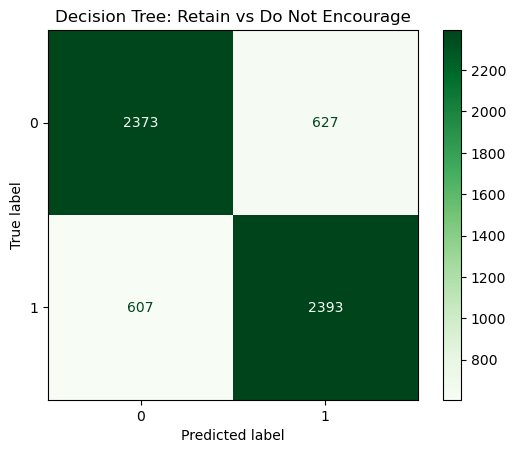

In [65]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_full, cmap="Greens")
plt.title("Decision Tree: Retain vs Do Not Encourage")
plt.show()

In [66]:
full_importance = pd.Series(
    dt_full.feature_importances_,
    index=X_full.columns
).sort_values(ascending=False)

full_importance.head(15)

credit_score              0.445649
savings_rate_pct          0.222290
investment_value_usd      0.108580
debt_to_income            0.108462
annual_income_usd         0.090981
insurance_value_usd       0.013847
overlimit_events_12m      0.007817
engagement_score          0.002058
product_count             0.000316
age                       0.000000
has_credit_card           0.000000
salary_account            0.000000
gender_M                  0.000000
has_mortgage              0.000000
marital_status_Married    0.000000
dtype: float64

In [67]:
from sklearn.feature_selection import f_classif

F_values, p_values = f_classif(X_full, y_full)

anova_results = pd.DataFrame({
    "Feature": X_full.columns,
    "F-value": F_values,
    "p-value": p_values
}).sort_values("F-value", ascending=False)

anova_results.to_csv("ANOVA_Feature_Importance.csv", index=False)
anova_results.head(15)

,Feature,F-value,p-value
3,credit_score,8482.815500,0.000000e+00
4,savings_rate_pct,3721.066376,0.000000e+00
2,annual_income_usd,2486.615064,0.000000e+00
21,debt_to_income,1979.473518,0.000000e+00
11,investment_value_usd,1759.332942,0.000000e+00
5,loan_amount_usd,1002.661984,1.747189e-216
15,overlimit_events_12m,945.039225,2.365664e-204
12,insurance_value_usd,828.886135,7.935245e-180
14,late_payments_24m,744.565210,5.812239e-162
6,product_count,681.846474,1.218657e-148


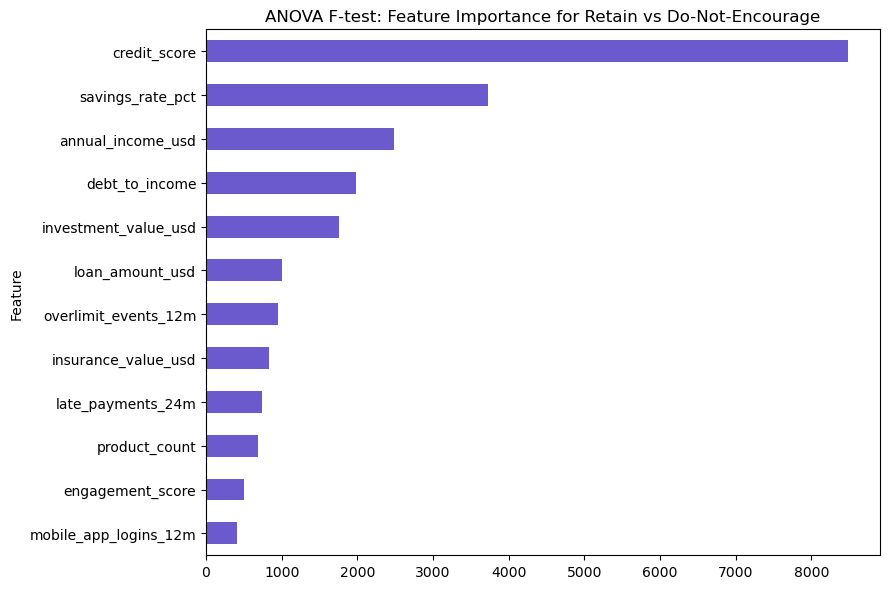

In [68]:
plt.figure(figsize=(9, 6))
anova_results.set_index("Feature")["F-value"].head(12).sort_values().plot(kind="barh", color="slateblue")
plt.title("ANOVA F-test: Feature Importance for Retain vs Do-Not-Encourage")
plt.tight_layout()
plt.savefig("anova_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

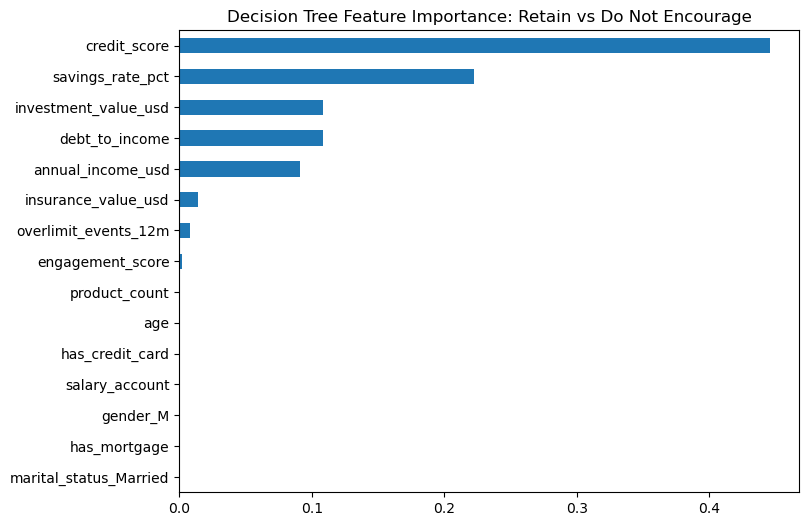

In [69]:
full_importance.head(15).plot(kind="barh", figsize=(8, 6))
plt.gca().invert_yaxis()
plt.title("Decision Tree Feature Importance: Retain vs Do Not Encourage")
plt.show()

### Validation Metrics & Confusion Matrices

In [70]:
clf_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_val, logreg_pred),
        "Precision": precision_score(y_val, logreg_pred),
        "Recall": recall_score(y_val, logreg_pred),
        "F1": f1_score(y_val, logreg_pred),
        "ROC-AUC": roc_auc_score(y_val, logreg_proba),
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_val, rf_pred),
        "Precision": precision_score(y_val, rf_pred),
        "Recall": recall_score(y_val, rf_pred),
        "F1": f1_score(y_val, rf_pred),
        "ROC-AUC": roc_auc_score(y_val, rf_proba),
    },
])
clf_comparison.to_csv("Retain_Classifier_Comparison.csv", index=False)
clf_comparison


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.971778,0.973461,0.970000,0.971728,0.997222
1,Random Forest,0.901333,0.905843,0.895778,0.900782,0.969712


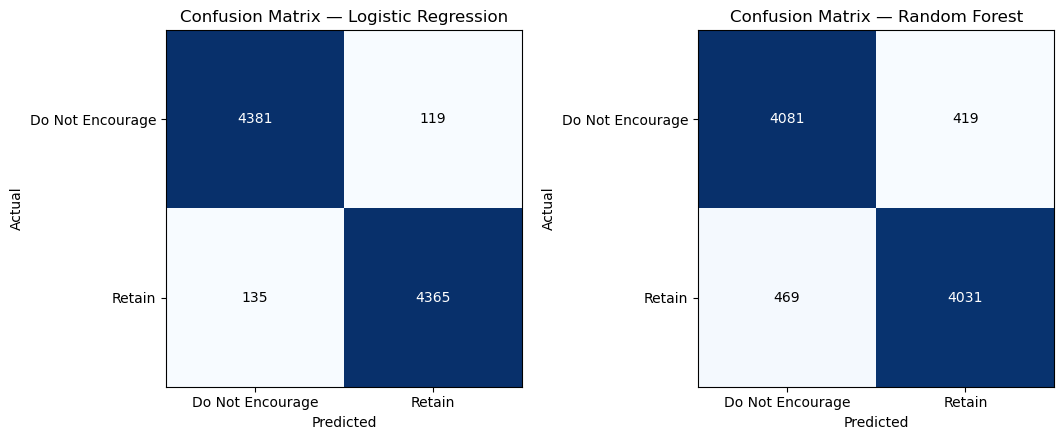

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, pred) in zip(axes, [("Logistic Regression", logreg_pred), ("Random Forest", rf_pred)]):
    cm = confusion_matrix(y_val, pred)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"Confusion Matrix — {name}")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Do Not Encourage", "Retain"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Do Not Encourage", "Retain"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.savefig("classifier_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


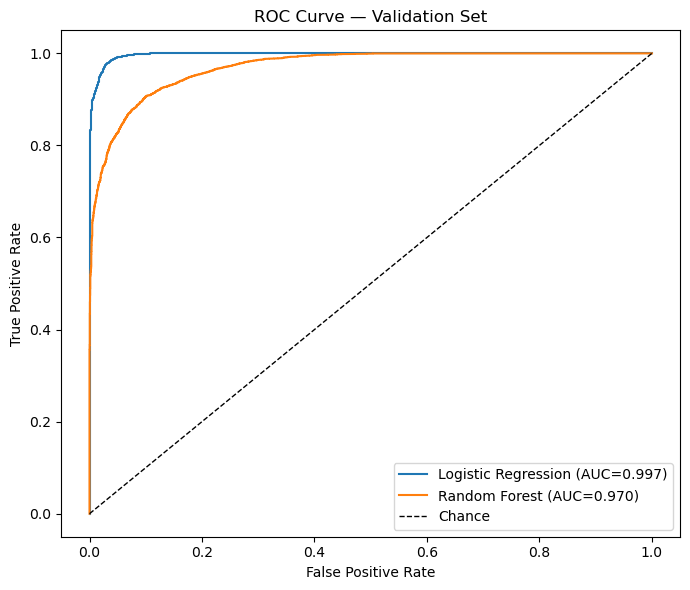

In [72]:
fpr_lr, tpr_lr, _ = roc_curve(y_val, logreg_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_val, rf_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={roc_auc_score(y_val, logreg_proba):.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_score(y_val, rf_proba):.3f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Validation Set")
plt.legend()
plt.tight_layout()
plt.savefig("classifier_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()


### Feature Importance / Business Read-out

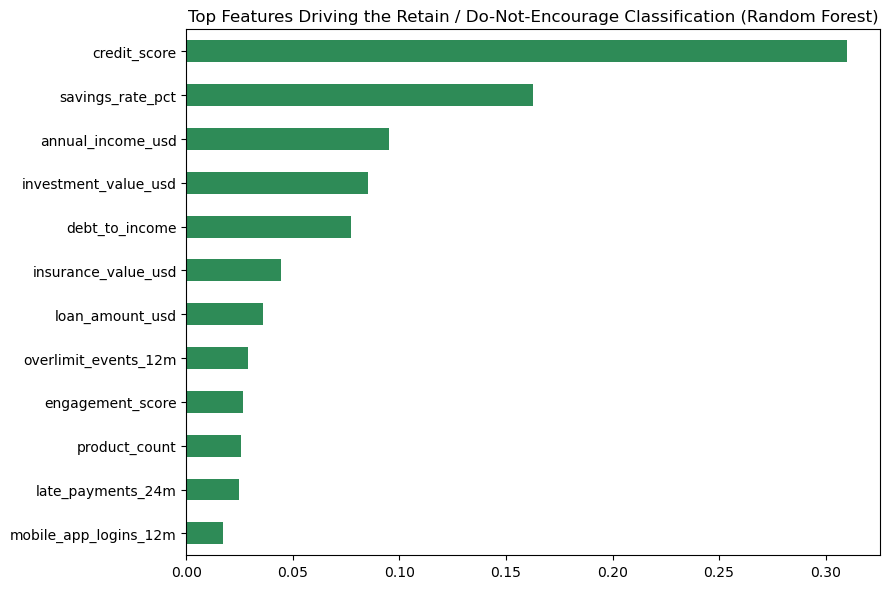

credit_score             0.310058
savings_rate_pct         0.162764
annual_income_usd        0.094913
investment_value_usd     0.085050
debt_to_income           0.077395
insurance_value_usd      0.044535
loan_amount_usd          0.035768
overlimit_events_12m     0.029081
engagement_score         0.026444
product_count            0.025789
late_payments_24m        0.024649
mobile_app_logins_12m    0.017212
dtype: float64

In [73]:
rf_importance = pd.Series(rf_clf.feature_importances_, index=clf_features).sort_values(ascending=False)
plt.figure(figsize=(9, 6))
rf_importance.head(12).sort_values().plot(kind="barh", color="seagreen")
plt.title("Top Features Driving the Retain / Do-Not-Encourage Classification (Random Forest)")
plt.tight_layout()
plt.savefig("classifier_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

rf_importance.head(12)


In [74]:
df.to_excel("Customer_Segmentation_Results_Extended.xlsx", index=False)
print("Saved: Customer_Segmentation_Results_Extended.xlsx")

final_summary = pd.DataFrame({
    "Metric": ["Optimal K-Means Clusters", "Silhouette Score", "Calinski-Harabasz", "Davies-Bouldin",
               "ARI numeric-only vs full-feature", "Best regression model", "Best regression R2",
               "Best classifier ROC-AUC"],
    "Value": [best_k, silhouette_score(X_scaled, clusters), calinski_harabasz_score(X_scaled, clusters),
              davies_bouldin_score(X_scaled, clusters), ari, best_reg_name, reg_results_df.iloc[0]["R2"],
              clf_comparison["ROC-AUC"].max()],
})
print("\nFinal model quality metrics:")
final_summary


Saved: Customer_Segmentation_Results_Extended.xlsx

Final model quality metrics:


,Metric,Value
0,Optimal K-Means Clusters,4
1,Silhouette Score,0.075242
2,Calinski-Harabasz,1561.025447
3,Davies-Bouldin,2.799662
4,ARI numeric-only vs full-feature,0.092952
5,Best regression model,Linear Regression
6,Best regression R2,1.0
7,Best classifier ROC-AUC,0.997222
